In [1]:
import symlib
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import colormaps
import matplotlib.colors as mcolors
import scipy
from scipy import stats

**Trying to make a global plotting function to make any relevant plots, similar to MATLAB:**

In [401]:
## global plotting variables
colors = ["black", "tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]
avg_colors = [(0,0,0), (102/225, 0/255, 110/255), (7/255, 0/255, 110/255), (22/255, 112/255, 0/255), (163/255, 90/255, 2/255), (128/255, 3/255, 3/255)]

## global data location variables
base_dir = "C:/Users/steph/Symphony"
suite_list = ["MWest", "SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#suite_list = ["MWest"]
redshifts = [2.0, 1.0, 0.5, 0.1, 0.0]

In [133]:
## plotting function pseudocode:

# def plotter(plot_type, ncols, nrows, figsize, etc etc)
    # if plot_type == "SHMF":
        # x_data, y_data = SHMF_data[0], SHMF_data[1]
        ## plot the histogram
    # if plot_type == "MAH":
        # x_data, y_data = MAH_data[0], MAH_data[1]
        ## make the plot

## i could make smaller functions to read in the data for MAH and SHMF, then have plotter call those?

In [402]:
def MAH_data(base_dir, suite_list):

    test1 = []
    test2 = []
    
    for suite_index, suite_name in enumerate(suite_list):
        print(suite_index + 1, suite_name)
        n_hosts = symlib.n_hosts(suite_name)

        masses_suite = np.zeros(n_hosts, dtype = "object")

        for i_host in range(n_hosts):
            sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
            h, hist = symlib.read_subhalos(sim_dir)
            scale_factors = symlib.scale_factors(sim_dir)

            params = symlib.simulation_parameters(sim_dir)
            particle_mass = params["mp"]
        
            host_mass = np.array(h["mvir"][0])
            num_particles = host_mass / particle_mass
            mass_cut = 300 * particle_mass
        
            host_mass_masked = np.where(host_mass < mass_cut, np.nan, host_mass)    # replace all entries < 300 particle masses with np.nan
            #ax.plot(scale_factors, host_mass_masked, color = colors[index], lw = 0.75, alpha = 0.33)
            masses_suite[i_host] = host_mass[0:236]
    
        vstacked_masses = np.vstack(masses_suite)

        test1.append(scale_factors)
        test2.append(vstacked_masses)

    return test1, test2

In [403]:
data = MAH_data(base_dir, suite_list)

1 MWest


KeyboardInterrupt: 

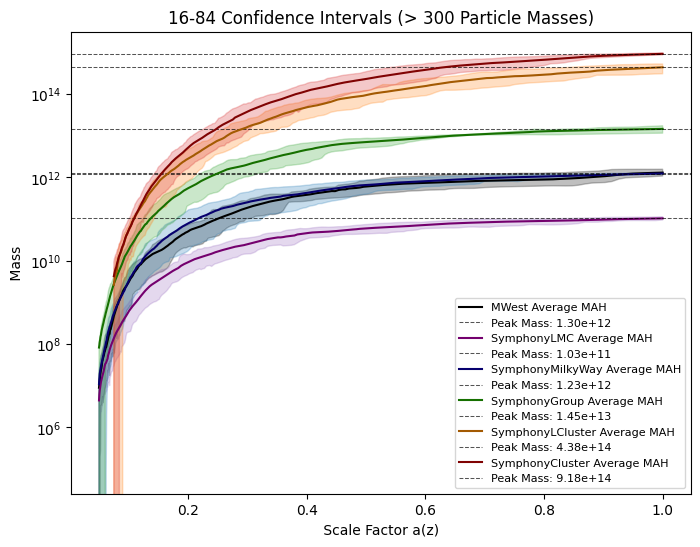

In [6]:
## this is the "plot" logic for the MAH plotting code

fig, ax = plt.subplots(figsize = (8,6))

scale_factors = data[0]
stacked_masses = data[1]

for arr_index, arr in enumerate(stacked_masses):
    avg_masses = np.mean(arr, axis = 0)
    percentile_16 = np.percentile(arr, 16, axis = 0)
    percentile_84 = np.percentile(arr, 84, axis = 0)
    
    ax.plot(scale_factors[arr_index], avg_masses, color = avg_colors[arr_index], label = f"{suite_list[arr_index]} Average MAH")
    ax.fill_between(scale_factors[arr_index], percentile_16, percentile_84, color = colors[arr_index], alpha = 0.25)
    ax.axhline(y = avg_masses[-1], color = "black", linestyle = '--', lw = 0.75, alpha = 0.67, label = f"Peak Mass: {(avg_masses[-1]):.2e}")
    
ax.set_yscale("log")
ax.set_xlabel(r" Scale Factor a(z) ", fontsize = 10)
ax.set_ylabel(r" Mass ", fontsize = 10)
#ax.set_ylim(1e2 * particle_mass, 1e8 * particle_mass)
#ax.set_ylim(5e6, 1e16)
ax.legend(loc = 'best', fontsize = 8)
ax.set_title(f"16-84 Confidence Intervals (> 300 Particle Masses)", loc = "center", fontsize = 12)
plt.show()

In [404]:
def SHMF_data(base_dir, suite_list, redshift_list):

    shmf_per_suite_redshift = np.zeros(len(redshift_list), dtype = "object")
    left_bins_per_suite = np.zeros(len(suite_list), dtype = "object")

    for z_index, target_z in enumerate(redshift_list):

        shmf_per_suite = np.zeros(len(suite_list), dtype = "object")
        
        for suite_index, suite_name in enumerate(suite_list):

            # create histogram bins
            params = symlib.simulation_parameters(suite_name)
            m_min = (300*params["mp"])/params["h100"]
            m_max = 1e15
            n_bins = 250
            bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
            left_bins = bins[:-1]

            n_hosts = symlib.n_hosts(suite_name)
            
            shmf = np.zeros((n_hosts, n_bins))

            for i_host in range(n_hosts):
                sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
                scale_factors = symlib.scale_factors(sim_dir)
                target_a = 1 / (1 + target_z)
                snap_index = np.argmin(np.abs(scale_factors - target_a))
                
                h, hist = symlib.read_subhalos(sim_dir)

                # figure out which subhalos exist within the virial radius of the host halo at a given snapshot
                r = np.sqrt(np.sum(h["x"][:, snap_index]**2, axis = 1))   # calculate the subhalo's distance
                host_rvir = h["rvir"][0, snap_index]                      # get the virial radius of the host halo
                ok = h["ok"][:, snap_index] & (r < host_rvir)             # only keep the halo if it's been okayed and inside the virial radius
                n_vir, _ = np.histogram(hist["mpeak"][ok][1:], bins = bins)      # add to histogram
                N_vir = np.cumsum(n_vir[::-1])[::-1]

                shmf[i_host, :] = N_vir

            shmf_per_suite[suite_index] = shmf
            left_bins_per_suite[suite_index] = left_bins
            
            print(target_z, suite_name, i_host, n_hosts)
            
        shmf_per_suite_redshift[z_index] = shmf_per_suite
    return shmf_per_suite_redshift, left_bins_per_suite

In [405]:
shmf_data = SHMF_data(base_dir, suite_list, redshifts)

2.0 MWest 19 20
2.0 SymphonyLMC 38 39
2.0 SymphonyMilkyWay 44 45
2.0 SymphonyGroup 48 49
2.0 SymphonyLCluster 32 33
2.0 SymphonyCluster 80 81
1.0 MWest 19 20
1.0 SymphonyLMC 38 39
1.0 SymphonyMilkyWay 44 45
1.0 SymphonyGroup 48 49
1.0 SymphonyLCluster 32 33
1.0 SymphonyCluster 80 81
0.5 MWest 19 20
0.5 SymphonyLMC 38 39
0.5 SymphonyMilkyWay 44 45
0.5 SymphonyGroup 48 49
0.5 SymphonyLCluster 32 33
0.5 SymphonyCluster 80 81
0.1 MWest 19 20
0.1 SymphonyLMC 38 39
0.1 SymphonyMilkyWay 44 45
0.1 SymphonyGroup 48 49
0.1 SymphonyLCluster 32 33
0.1 SymphonyCluster 80 81
0.0 MWest 19 20
0.0 SymphonyLMC 38 39
0.0 SymphonyMilkyWay 44 45
0.0 SymphonyGroup 48 49
0.0 SymphonyLCluster 32 33
0.0 SymphonyCluster 80 81


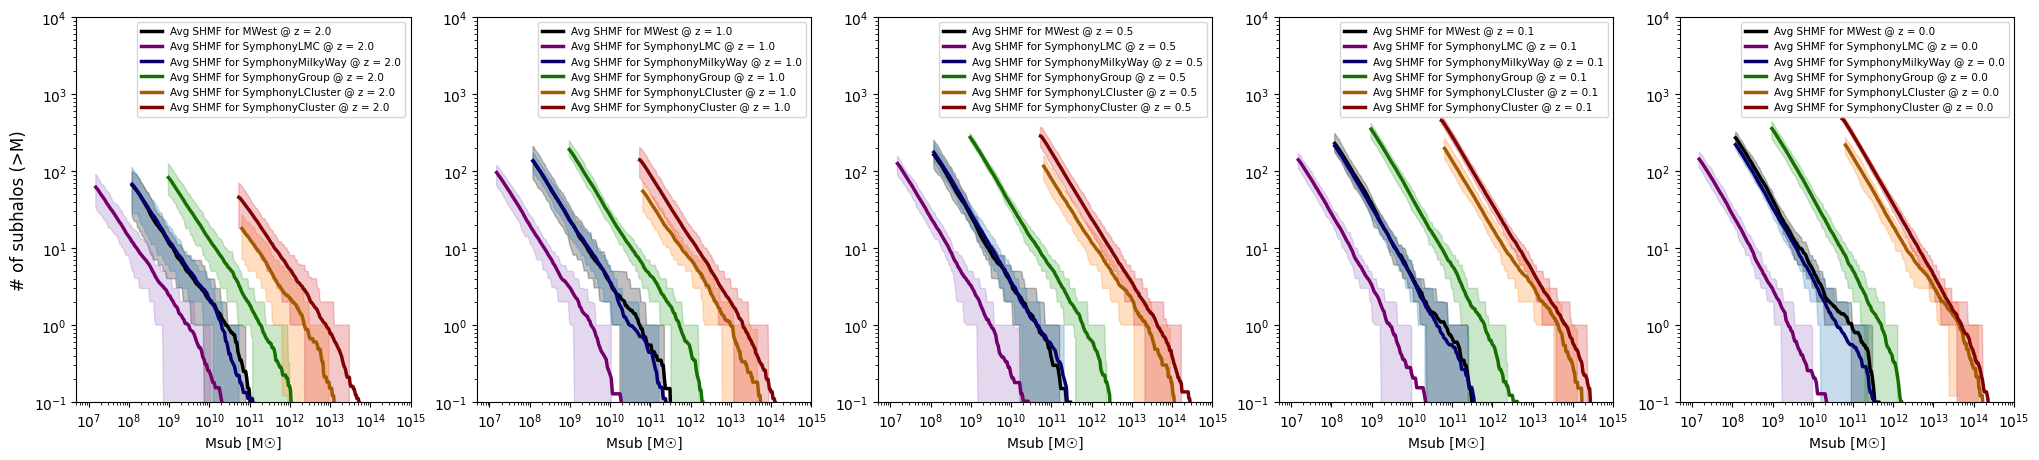

In [408]:
fig, ax = plt.subplots(ncols = len(redshifts), nrows = 1, figsize = (25,5))

for redshift_index in range(len(shmf_data[0])):

    for suite_index in range(len(shmf_data[1])):

        #print(redshift_index)
    
        left_bins = shmf_data[1][suite_index]
        hist_data = shmf_data[0][redshift_index][suite_index]

        percentile_16 = np.percentile(hist_data, 16, axis = 0)
        percentile_84 = np.percentile(hist_data, 84, axis = 0)
        
        avg_hist = np.mean(hist_data, axis = 0)
        ax[redshift_index].plot(left_bins, avg_hist, color = avg_colors[suite_index], lw = 2.5,
                                label = f"Avg SHMF for {suite_list[suite_index]} @ z = {redshifts[redshift_index]}")
        ax[redshift_index].fill_between(left_bins, percentile_16, percentile_84, color = colors[suite_index], alpha = 0.25)
        ax[redshift_index].set_xscale("log")
        ax[redshift_index].set_yscale("log")
        ax[redshift_index].set_xlim(5e6, 1e15)
        ax[redshift_index].set_ylim(1e-1, 1e4)

        #axs.fill_between(left_bins, percentile_16, percentile_84, color = og_colors[suite_index], alpha = 0.25)
        ax[redshift_index].set_xlabel("Msub [M☉]", fontsize = 10)
        ax[0].set_ylabel("# of subhalos (>M)", fontsize = 12)
        ax[redshift_index].legend(loc = "best", fontsize = 7.5)

        #for histindex, hist in enumerate(hist_data):
        #    ax[redshift_index].plot(left_bins, hist, color = colors[suite_index], alpha = 0.15)
        #    ax[redshift_index].set_xscale("log")
        #    ax[redshift_index].set_yscale("log")

#fig.supxlabel("Msub [M☉]", fontsize = 12)
#fig.suptitle(f"SHMF Of All Suites", fontsize = 12)
plt.show()